=== RESULTADOS ANOVA ===
               sum_sq    df           F        PR(>F)
C(grupo)  4263.466667   2.0  118.065231  4.478170e-14
Residual   487.500000  27.0         NaN           NaN

=== Estadísticos de la prueba ===
F observado: 118.0652
F crítico (α=0.05): 3.3541
p-valor: 0.0000
➡ Se RECHAZA H₀: existen diferencias significativas entre las medias.


/tmp/ipython-input-2365828728.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  F_observado = anova_tabla['F'][0]
/tmp/ipython-input-2365828728.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_valor = anova_tabla['PR(>F)'][0]



=== Comparación post-hoc (Tukey HSD) ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
    G1     G2     14.8   0.0  10.0884  19.5116   True
    G1     G3    -14.4   0.0 -19.1116  -9.6884   True
    G2     G3    -29.2   0.0 -33.9116 -24.4884   True
-----------------------------------------------------


/tmp/ipython-input-2365828728.py:66: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.barplot(x='grupo', y='tiempo', data=datos, ci=95, palette='Set2')
/tmp/ipython-input-2365828728.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grupo', y='tiempo', data=datos, ci=95, palette='Set2')


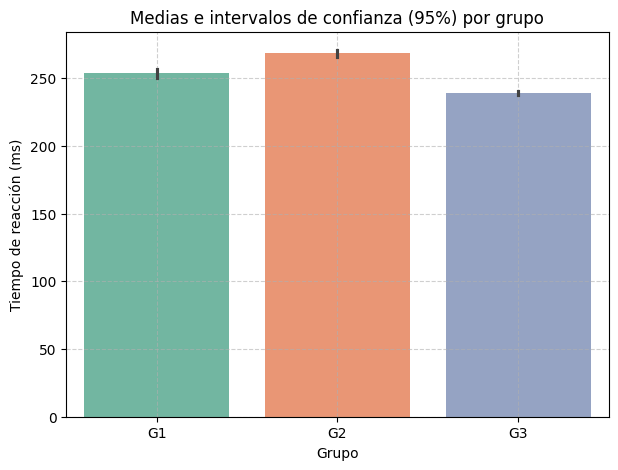

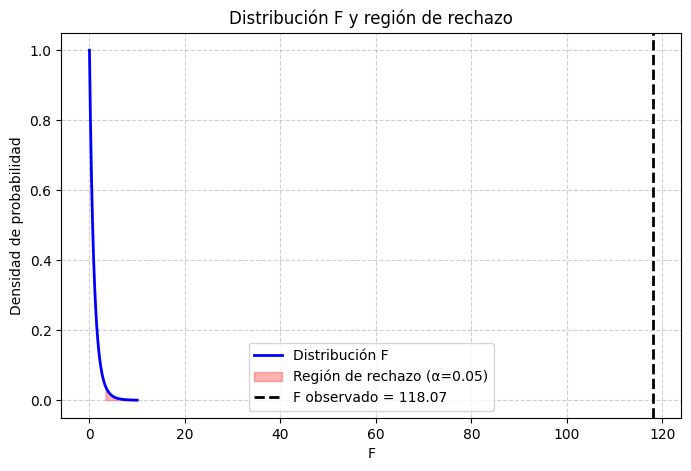

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# Datos
# =========================================
grupo1 = np.array([250, 260, 245, 255, 248, 252, 258, 261, 249, 257])
grupo2 = np.array([265, 270, 260, 275, 268, 267, 272, 269, 271, 266])
grupo3 = np.array([240, 235, 242, 238, 236, 239, 241, 237, 243, 240])

# Crear DataFrame
datos = pd.DataFrame({
    'tiempo': np.concatenate([grupo1, grupo2, grupo3]),
    'grupo': ['G1'] * len(grupo1) + ['G2'] * len(grupo2) + ['G3'] * len(grupo3)
})

# =========================================
# ANOVA de una vía
# =========================================
modelo = ols('tiempo ~ C(grupo)', data=datos).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

print("=== RESULTADOS ANOVA ===")
print(anova_tabla)

# Parámetros de la prueba
k = 3  # número de grupos
n_total = len(datos)
df_entre = k - 1
df_dentro = n_total - k
alpha = 0.05

F_observado = anova_tabla['F'][0]
p_valor = anova_tabla['PR(>F)'][0]
F_critico = stats.f.ppf(1 - alpha, df_entre, df_dentro)

print("\n=== Estadísticos de la prueba ===")
print(f"F observado: {F_observado:.4f}")
print(f"F crítico (α={alpha}): {F_critico:.4f}")
print(f"p-valor: {p_valor:.4f}")

if F_observado > F_critico:
    print("➡ Se RECHAZA H₀: existen diferencias significativas entre las medias.")
else:
    print("➡ No se rechaza H₀: no hay evidencia de diferencias significativas entre las medias.")

# =========================================
# Comparación post-hoc (Tukey HSD)
# =========================================
tukey = pairwise_tukeyhsd(endog=datos['tiempo'],
                          groups=datos['grupo'],
                          alpha=alpha)
print("\n=== Comparación post-hoc (Tukey HSD) ===")
print(tukey)

# =========================================
# Visualización de medias e IC 95%
# =========================================
plt.figure(figsize=(7, 5))
sns.barplot(x='grupo', y='tiempo', data=datos, ci=95, palette='Set2')
plt.title('Medias e intervalos de confianza (95%) por grupo')
plt.xlabel('Grupo')
plt.ylabel('Tiempo de reacción (ms)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# =========================================
# Gráfico de la distribución F y región de rechazo
# =========================================
x = np.linspace(0, 10, 500)
y = stats.f.pdf(x, df_entre, df_dentro)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', lw=2, label='Distribución F')
plt.fill_between(x, y, where=(x >= F_critico), color='red', alpha=0.3,
                 label=f'Región de rechazo (α={alpha})')
plt.axvline(F_observado, color='black', linestyle='--', lw=2,
            label=f'F observado = {F_observado:.2f}')
plt.title('Distribución F y región de rechazo')
plt.xlabel('F')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


=== Tabla ANOVA ===
Fuente de variación          SC  gl          CM           F
       Entre grupos 1605.166667   2  802.583333  260.724364
   Dentro de grupos  101.583333  33    3.078283            
              Total 1706.750000  35                        

Valor crítico F(α=0.01): 5.312
Estadístico F calculado: 260.7244
p-valor: 0.0

❌ Se rechaza H₀: Al menos una media poblacional difiere.


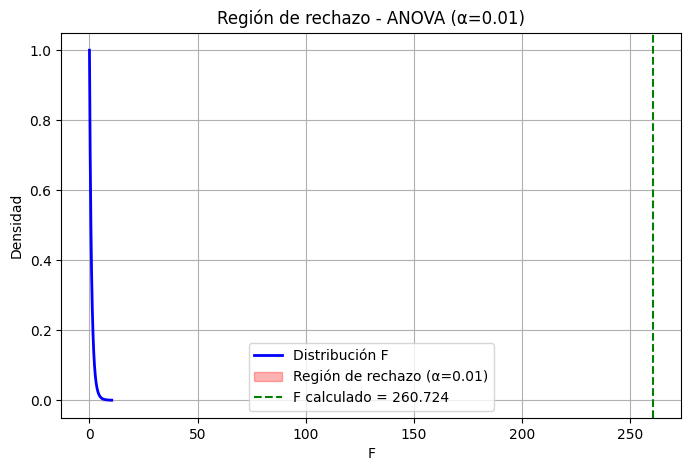


=== Prueba Post-hoc de Tukey (α = 0.01) ===
  group1   group2  meandiff  p-adj    lower    upper  reject
Método A Método B    7.4167    0.0   5.1767   9.6567    True
Método A Método C   -8.9167    0.0 -11.1567  -6.6767    True
Método B Método C  -16.3333    0.0 -18.5733 -14.0933    True


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =======================
# Datos
# =======================
A = np.array([78, 80, 76, 82, 79, 81, 77, 80, 83, 79, 78, 80])
B = np.array([85, 88, 84, 87, 86, 89, 90, 85, 87, 88, 86, 87])
C = np.array([70, 72, 68, 71, 69, 73, 70, 72, 71, 70, 69, 71])

# =======================
# ANOVA de una vía
# =======================
f_stat, p_val = stats.f_oneway(A, B, C)

# Parámetros
k = 3  # número de grupos
n = len(A) + len(B) + len(C)
df_between = k - 1
df_within = n - k

# Cálculo manual de sumas de cuadrados
grand_mean = np.mean(np.concatenate([A, B, C]))
ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in [A, B, C])
ss_within = sum(sum((g - np.mean(g))**2) for g in [A, B, C])

ms_between = ss_between / df_between
ms_within = ss_within / df_within

# Valor crítico F
alpha = 0.01
f_crit = stats.f.ppf(1 - alpha, df_between, df_within)

# =======================
# Tabla ANOVA
# =======================
anova_table = pd.DataFrame({
    'Fuente de variación': ['Entre grupos', 'Dentro de grupos', 'Total'],
    'SC': [ss_between, ss_within, ss_between + ss_within],
    'gl': [df_between, df_within, df_between + df_within],
    'CM': [ms_between, ms_within, ''],
    'F': [f_stat, '', '']
})

print("\n=== Tabla ANOVA ===")
print(anova_table.to_string(index=False))
print("\nValor crítico F(α=0.01):", round(f_crit, 4))
print("Estadístico F calculado:", round(f_stat, 4))
print("p-valor:", round(p_val, 6))

if f_stat > f_crit:
    print("\n❌ Se rechaza H₀: Al menos una media poblacional difiere.")
else:
    print("\n✅ No se rechaza H₀: No hay evidencia suficiente para diferencias entre medias.")

# =======================
# Gráfico de región de rechazo
# =======================
x = np.linspace(0, f_crit + 5, 500)
y = stats.f.pdf(x, df_between, df_within)

plt.figure(figsize=(8,5))
plt.plot(x, y, 'b-', lw=2, label='Distribución F')
plt.fill_between(x, y, where=(x >= f_crit), color='red', alpha=0.3, label='Región de rechazo (α=0.01)')
plt.axvline(f_stat, color='green', linestyle='--', label=f'F calculado = {f_stat:.3f}')
plt.title('Región de rechazo - ANOVA (α=0.01)')
plt.xlabel('F')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

# =======================
# Prueba post-hoc Tukey HSD
# =======================
data = np.concatenate([A, B, C])
labels = (['Método A'] * len(A)) + (['Método B'] * len(B)) + (['Método C'] * len(C))

tukey = pairwise_tukeyhsd(endog=data, groups=labels, alpha=0.01)

# Mostrar tabla Tukey
print("\n=== Prueba Post-hoc de Tukey (α = 0.01) ===")
tukey_table = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
print(tukey_table.to_string(index=False))

=== TABLA ANOVA ===
                  sum_sq    df          F        PR(>F)
C(fertilizante)  136.375   3.0  51.952381  1.449003e-11
Residual          24.500  28.0        NaN           NaN

Resultados clave:
df_between = 3, df_within = 28
SS_between = 136.3750, SS_within = 24.5000
MS_between = 45.4583, MSE = 0.8750
F observado = 51.9524
p-valor = 0.000000
F crítico (α = 0.05) = 2.9467
Decisión: Rechazamos H0 -> existen diferencias significativas entre al menos dos medias.

=== PRUEBA DE TUKEY (HSD) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
    F1     F2      3.0    0.0  1.723  4.277   True
    F1     F3     0.25 0.9499 -1.027  1.527  False
    F1     F4      5.0    0.0  3.723  6.277   True
    F2     F3    -2.75    0.0 -4.027 -1.473   True
    F2     F4      2.0 0.0011  0.723  3.277   True
    F3     F4     4.75    0.0  3.473  6.027   True
---------------------------------

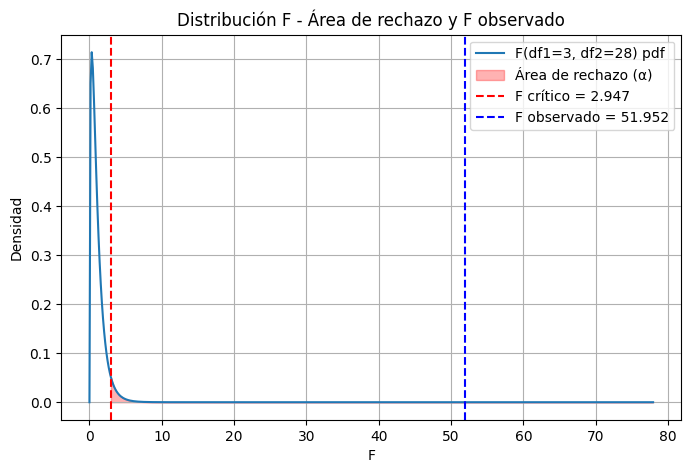

In [12]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

# Datos
fert1 = [15, 16, 14, 17, 15, 16, 14, 15]
fert2 = [18, 17, 19, 18, 17, 20, 19, 18]
fert3 = [16, 15, 16, 15, 16, 15, 16, 15]
fert4 = [20, 21, 19, 20, 22, 21, 20, 19]

data = pd.DataFrame({
    'altura': fert1 + fert2 + fert3 + fert4,
    'fertilizante': (['F1']*len(fert1) + ['F2']*len(fert2) +
                     ['F3']*len(fert3) + ['F4']*len(fert4))
})

alpha = 0.05

# ANOVA (modelo y tabla)
modelo = ols('altura ~ C(fertilizante)', data=data).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)  # tabla ANOVA

# Extraer valores importantes
df_between = anova_tabla['df']['C(fertilizante)']
df_within = anova_tabla['df']['Residual']
ss_between = anova_tabla['sum_sq']['C(fertilizante)']
ss_within = anova_tabla['sum_sq']['Residual']
ms_between = anova_tabla['sum_sq']['C(fertilizante)'] / df_between
MSE = ss_within / df_within
F_obs = ms_between / MSE
p_value = 1 - stats.f.cdf(F_obs, df_between, df_within)
F_crit = stats.f.ppf(1 - alpha, df_between, df_within)

print("=== TABLA ANOVA ===")
print(anova_tabla)
print("\nResultados clave:")
print(f"df_between = {df_between:.0f}, df_within = {df_within:.0f}")
print(f"SS_between = {ss_between:.4f}, SS_within = {ss_within:.4f}")
print(f"MS_between = {ms_between:.4f}, MSE = {MSE:.4f}")
print(f"F observado = {F_obs:.4f}")
print(f"p-valor = {p_value:.6f}")
print(f"F crítico (α = {alpha}) = {F_crit:.4f}")
if F_obs > F_crit:
    print("Decisión: Rechazamos H0 -> existen diferencias significativas entre al menos dos medias.")
else:
    print("Decisión: No rechazamos H0 -> no hay evidencia suficiente de diferencias entre medias.")

# Tukey HSD
tukey = pairwise_tukeyhsd(endog=data['altura'],
                          groups=data['fertilizante'],
                          alpha=alpha)
print("\n=== PRUEBA DE TUKEY (HSD) ===")
print(tukey)

# Cálculo manual de HSD (usa studentized range q crit)
k = data['fertilizante'].nunique()
# Suponiendo tamaños iguales por grupo (n)
n_per_group = data.groupby('fertilizante').size().iloc[0]
df_error = df_within
q_crit = stats.studentized_range.ppf(1 - alpha, k, df_error)
HSD = q_crit * np.sqrt(MSE / n_per_group)

print(f"\nq crítico (studentized range) = {q_crit:.4f}")
print(f"HSD = {HSD:.4f} (diferencia mínima significativa entre medias)")

# Mostrar medias por grupo y diferencias para comparar con HSD
means = data.groupby('fertilizante')['altura'].mean().sort_index()
print("\nMedias por grupo:")
print(means)
print("\nDiferencias absolutas entre pares (comparar con HSD):")
pairs = []
labels = means.index.tolist()
for i in range(len(labels)):
    for j in range(i+1, len(labels)):
        diff = abs(means.iloc[i] - means.iloc[j])
        pairs.append((labels[i], labels[j], diff))
for a,b,d in pairs:
    sig = ">" if d > HSD else "<="
    print(f"{a} vs {b}: |{d:.4f}| {sig} HSD")

# GRAFICA: Distribución F, área de rechazo y F observado
x_max = max(F_crit*2.5, F_obs*1.5, 5)
x = np.linspace(0, x_max, 500)
f_pdf = stats.f.pdf(x, df_between, df_within)

plt.figure(figsize=(8,5))
plt.plot(x, f_pdf, label=f"F(df1={int(df_between)}, df2={int(df_within)}) pdf")
plt.fill_between(x, where=(x >= F_crit), y1=0, y2=stats.f.pdf(x, df_between, df_within),
                 color='red', alpha=0.3, label='Área de rechazo (α)')
plt.axvline(F_crit, color='red', linestyle='--', label=f"F crítico = {F_crit:.3f}")
plt.axvline(F_obs, color='blue', linestyle='--', label=f"F observado = {F_obs:.3f}")
plt.title("Distribución F - Área de rechazo y F observado")
plt.xlabel("F")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.show()


=== TABLA ANOVA ===
                sum_sq    df     F        PR(>F)
C(tecnica)  232.296296   2.0  98.0  2.840944e-12
Residual     28.444444  24.0   NaN           NaN

=== PRUEBA DE TUKEY HSD ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    T1     T2   4.4444    0.0  3.1628  5.7261   True
    T1     T3  -2.6667 0.0001 -3.9483 -1.3851   True
    T2     T3  -7.1111    0.0 -8.3927 -5.8295   True
----------------------------------------------------


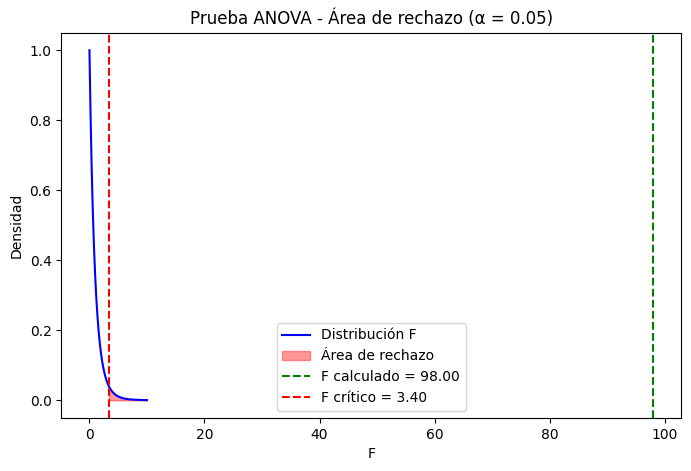


=== INTERPRETACIÓN ===
F calculado (98.00) > F crítico (3.40) → Se rechaza H₀.
Conclusión: Hay diferencias significativas entre al menos dos técnicas.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# =============================
# DATOS
# =============================
tecnica1 = [30, 32, 31, 29, 30, 33, 32, 31, 30]
tecnica2 = [35, 36, 34, 35, 37, 36, 34, 35, 36]
tecnica3 = [28, 27, 29, 28, 30, 29, 28, 27, 28]

# Crear DataFrame
data = pd.DataFrame({
    'concentracion': tecnica1 + tecnica2 + tecnica3,
    'tecnica': (['T1'] * len(tecnica1)) + (['T2'] * len(tecnica2)) + (['T3'] * len(tecnica3))
})

# =============================
# ANOVA de una vía
# =============================
modelo = ols('concentracion ~ C(tecnica)', data=data).fit()
anova = sm.stats.anova_lm(modelo, typ=2)
print("\n=== TABLA ANOVA ===")
print(anova)

# =============================
# Prueba de Tukey HSD
# =============================
tukey = pairwise_tukeyhsd(endog=data['concentracion'],
                          groups=data['tecnica'],
                          alpha=0.05)
print("\n=== PRUEBA DE TUKEY HSD ===")
print(tukey.summary())

# =============================
# Gráfico: Área de rechazo
# =============================
alpha = 0.05
gl_b = anova['df']['C(tecnica)']   # grados de libertad entre grupos
gl_w = anova['df']['Residual']     # grados de libertad dentro de grupos
F_calculado = anova['F']['C(tecnica)']
F_critico = stats.f.ppf(1 - alpha, gl_b, gl_w)

# Curva F
x = np.linspace(0, 10, 500)
y = stats.f.pdf(x, gl_b, gl_w)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', label='Distribución F')
plt.fill_between(x, 0, y, where=(x >= F_critico), color='red', alpha=0.4, label='Área de rechazo')
plt.axvline(F_calculado, color='green', linestyle='--', label=f'F calculado = {F_calculado:.2f}')
plt.axvline(F_critico, color='red', linestyle='--', label=f'F crítico = {F_critico:.2f}')
plt.title('Prueba ANOVA - Área de rechazo (α = 0.05)')
plt.xlabel('F')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# =============================
# Interpretación
# =============================
print("\n=== INTERPRETACIÓN ===")
if F_calculado > F_critico:
    print(f"F calculado ({F_calculado:.2f}) > F crítico ({F_critico:.2f}) → Se rechaza H₀.")
    print("Conclusión: Hay diferencias significativas entre al menos dos técnicas.")
else:
    print(f"F calculado ({F_calculado:.2f}) ≤ F crítico ({F_critico:.2f}) → No se rechaza H₀.")
    print("Conclusión: No hay diferencias significativas entre las técnicas.")


=== TABLA ANOVA ===
                sum_sq    df           F        PR(>F)
C(tratamiento)   369.8   3.0  114.963731  1.689009e-18
Residual          38.6  36.0         NaN           NaN

F_obtenido = 114.9637
F_crítico (α=0.05) = 2.8663
p-valor = 0.0000

Se RECHAZA H0: existen diferencias significativas entre tratamientos.



/tmp/ipython-input-1208789588.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  F_obtenido = anova_tabla['F'][0]
/tmp/ipython-input-1208789588.py:37: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_valor = anova_tabla['PR(>F)'][0]
/tmp/ipython-input-1208789588.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  gl_entre = anova_tabla['df'][0]
/tmp/ipython-input-1208789588.py:39: FutureWarning: Series.__getitem__ treating keys as

=== PRUEBA POST-HOC DE TUKEY ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B      4.5    0.0  3.2528  5.7472   True
     A      C      1.0 0.1542 -0.2472  2.2472  False
     A      D      7.7    0.0  6.4528  8.9472   True
     B      C     -3.5    0.0 -4.7472 -2.2528   True
     B      D      3.2    0.0  1.9528  4.4472   True
     C      D      6.7    0.0  5.4528  7.9472   True
----------------------------------------------------


/tmp/ipython-input-1208789588.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  MSW = anova_tabla['sum_sq'][1] / gl_dentro



HSD (Diferencia Honesta Significativa): 1.2472


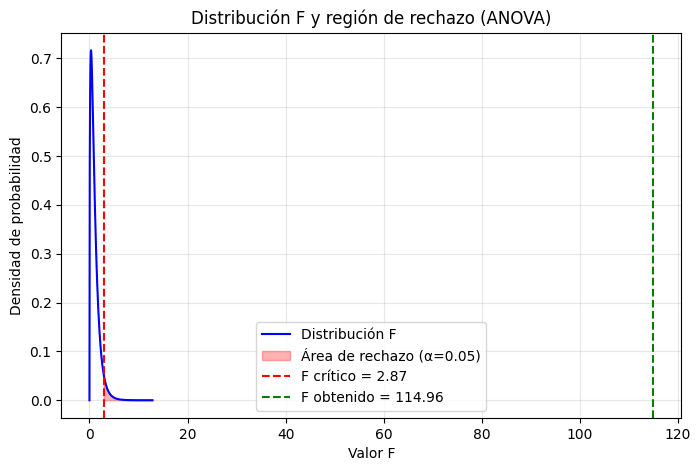

In [9]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

for var in ['C']:
    if var in globals():
        del globals()[var]
# ==============================
# DATOS
# ==============================
A = [20, 22, 19, 21, 20, 23, 22, 21, 20, 22]
B = [25, 24, 26, 27, 25, 26, 24, 27, 26, 25]
C_ = [22, 23, 21, 22, 21, 23, 22, 21, 22, 23]   # renombrado
D = [28, 29, 27, 30, 29, 28, 29, 30, 28, 29]

# Convertir a DataFrame
data = pd.DataFrame({
    'altura': A + B + C_ + D,
    'tratamiento': ['A']*len(A) + ['B']*len(B) + ['C']*len(C_) + ['D']*len(D)
})

# ==============================
# ANOVA DE UN FACTOR
# ==============================
modelo = ols('altura ~ C(tratamiento)', data=data).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

print("\n=== TABLA ANOVA ===")
print(anova_tabla)

# Obtener valores necesarios
F_obtenido = anova_tabla['F'][0]
p_valor = anova_tabla['PR(>F)'][0]
gl_entre = anova_tabla['df'][0]
gl_dentro = anova_tabla['df'][1]
alpha = 0.05
F_critico = stats.f.ppf(1 - alpha, gl_entre, gl_dentro)

# ==============================
# DECISIÓN
# ==============================
print(f"\nF_obtenido = {F_obtenido:.4f}")
print(f"F_crítico (α=0.05) = {F_critico:.4f}")
print(f"p-valor = {p_valor:.4f}")

if p_valor < alpha:
    print("\nSe RECHAZA H0: existen diferencias significativas entre tratamientos.\n")
else:
    print("\nNo se rechaza H0: no hay diferencias significativas.\n")

# ==============================
# PRUEBA DE TUKEY (si aplica)
# ==============================
if p_valor < alpha:
    tukey = pairwise_tukeyhsd(endog=data['altura'], groups=data['tratamiento'], alpha=alpha)
    print("=== PRUEBA POST-HOC DE TUKEY ===")
    print(tukey.summary())

    # Calcular HSD (Honest Significant Difference)
    n_i = len(A)
    MSW = anova_tabla['sum_sq'][1] / gl_dentro
    q_critico = stats.studentized_range.ppf(1 - alpha, len([A, B, C_, D]), gl_dentro)
    HSD = q_critico * np.sqrt(MSW / n_i)
    print(f"\nHSD (Diferencia Honesta Significativa): {HSD:.4f}")

    # ==============================
    # GRÁFICO: ÁREA DE RECHAZO
    # ==============================
    x = np.linspace(0, F_critico + 10, 400)
    y = stats.f.pdf(x, gl_entre, gl_dentro)

    plt.figure(figsize=(8,5))
    plt.plot(x, y, label='Distribución F', color='blue')
    plt.fill_between(x, y, where=(x >= F_critico), color='red', alpha=0.3, label='Área de rechazo (α=0.05)')
    plt.axvline(F_critico, color='red', linestyle='--', label=f'F crítico = {F_critico:.2f}')
    plt.axvline(F_obtenido, color='green', linestyle='--', label=f'F obtenido = {F_obtenido:.2f}')
    plt.title('Distribución F y región de rechazo (ANOVA)')
    plt.xlabel('Valor F')
    plt.ylabel('Densidad de probabilidad')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


=== Tabla ANOVA de dos vías ===
                              sum_sq    df           F        PR(>F)
C(Tratamiento)            717.388889   2.0  173.561828  3.232676e-17
C(Genero)                   0.111111   1.0    0.053763  8.182138e-01
C(Tratamiento):C(Genero)    1.055556   2.0    0.255376  7.762918e-01
Residual                   62.000000  30.0         NaN           NaN

=== Prueba de Tukey (Tratamiento) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper  reject
----------------------------------------------------
     X      Y      6.0   0.0    4.614   7.386   True
     X      Z  -4.9167   0.0  -6.3026 -3.5307   True
     Y      Z -10.9167   0.0 -12.3026 -9.5307   True
----------------------------------------------------


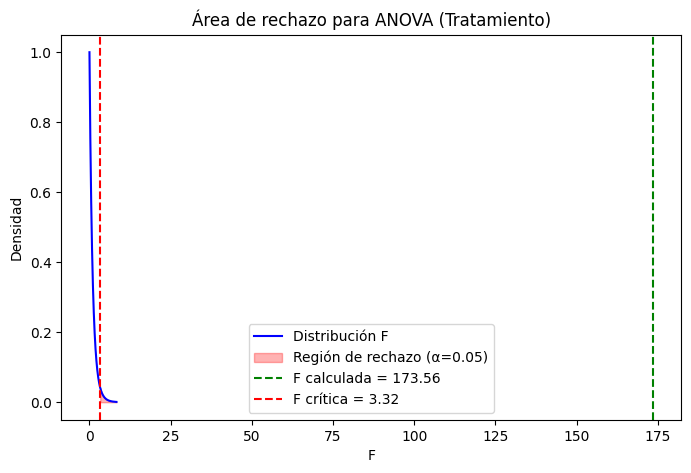

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f

# ======================================
# 1. Datos
# ======================================
X = [130, 128, 132, 131, 129, 130, 132, 133, 129, 130, 128, 131]
Y = [135, 137, 136, 134, 138, 137, 136, 139, 135, 137, 136, 135]
Z = [125, 127, 124, 126, 125, 126, 124, 125, 127, 125, 126, 124]

# Simulamos género alternando: 6 hombres y 6 mujeres por grupo
generos = ["H"] * 6 + ["M"] * 6

# Creamos DataFrame
data = pd.DataFrame({
    "Presion": X + Y + Z,
    "Tratamiento": ["X"] * 12 + ["Y"] * 12 + ["Z"] * 12,
    "Genero": generos * 3
})

# ======================================
# 2. ANOVA de dos vías
# ======================================
modelo = ols('Presion ~ C(Tratamiento) + C(Genero) + C(Tratamiento):C(Genero)', data=data).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)
print("\n=== Tabla ANOVA de dos vías ===")
print(anova_tabla)

# ======================================
# 3. Prueba de Tukey (para tratamiento)
# ======================================
tukey = pairwise_tukeyhsd(endog=data['Presion'],
                          groups=data['Tratamiento'],
                          alpha=0.05)
print("\n=== Prueba de Tukey (Tratamiento) ===")
print(tukey)

# ======================================
# 4. Gráfico: área de rechazo y valor crítico
# ======================================
# Extraemos valores para el gráfico
f_value = anova_tabla.loc["C(Tratamiento)", "F"]
df1 = anova_tabla.loc["C(Tratamiento)", "df"]
df2 = anova_tabla.loc["Residual", "df"]

# Valor crítico para α = 0.05
alpha = 0.05
f_crit = f.ppf(1 - alpha, df1, df2)

# Distribución F
x = np.linspace(0, f_crit + 5, 500)
y = f.pdf(x, df1, df2)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', label='Distribución F')
plt.fill_between(x, y, 0, where=(x > f_crit), color='red', alpha=0.3, label='Región de rechazo (α=0.05)')
plt.axvline(f_value, color='green', linestyle='--', label=f'F calculada = {f_value:.2f}')
plt.axvline(f_crit, color='red', linestyle='--', label=f'F crítica = {f_crit:.2f}')
plt.title('Área de rechazo para ANOVA (Tratamiento)')
plt.xlabel('F')
plt.ylabel('Densidad')
plt.legend()
plt.show()


=== Tabla ANOVA de dos vías con interacción ===
                          sum_sq    df           F        PR(>F)
C(Método)             876.400000   2.0  273.875000  1.664796e-22
C(Docente)              1.733333   2.0    0.541667  5.864449e-01
C(Método):C(Docente)    1.466667   4.0    0.229167  9.202264e-01
Residual               57.600000  36.0         NaN           NaN


/tmp/ipython-input-36743252.py:43: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_between = int(anova_tabla['df'][0])   # gl del primer factor
/tmp/ipython-input-36743252.py:44: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_within = int(anova_tabla['df'][-1])   # gl del error


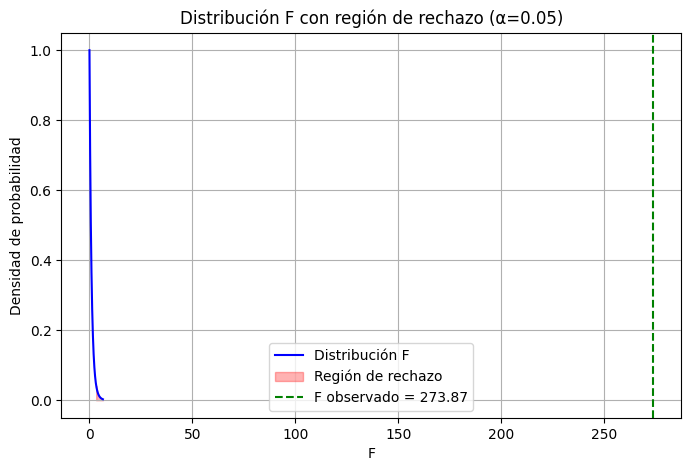


=== Prueba de Tukey (Método) ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower   upper  reject
--------------------------------------------------
     A      B      5.0   0.0 3.9326  6.0674   True
     A      C     10.8   0.0 9.7326 11.8674   True
     B      C      5.8   0.0 4.7326  6.8674   True
--------------------------------------------------


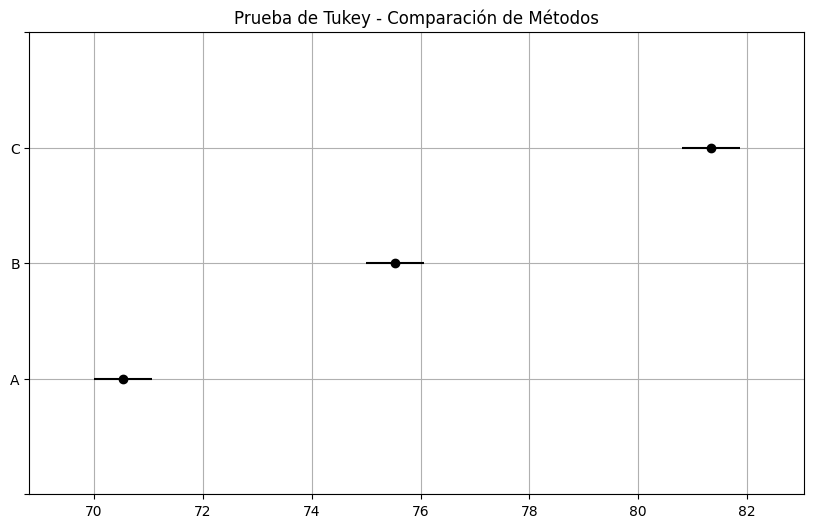

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ===============================================
# 1. Datos del problema
# ===============================================
metodo_A = [70, 72, 68, 71, 70, 69, 73, 72, 70, 71, 69, 70, 72, 71, 70]
metodo_B = [75, 76, 74, 75, 77, 76, 75, 74, 78, 76, 75, 77, 76, 75, 74]
metodo_C = [80, 82, 81, 83, 82, 80, 81, 82, 83, 81, 80, 82, 81, 80, 82]

# Supongamos que cada método fue aplicado por 3 docentes (5 alumnos por docente)
docentes = ['Docente 1', 'Docente 2', 'Docente 3']
datos = []

# Crear la estructura Método × Docente × Calificación
for i, metodo in enumerate(['A', 'B', 'C']):
    calificaciones = [metodo_A, metodo_B, metodo_C][i]
    for j, docente in enumerate(docentes):
        subgrupo = calificaciones[j*5:(j+1)*5]
        for nota in subgrupo:
            datos.append([metodo, docente, nota])

df = pd.DataFrame(datos, columns=['Método', 'Docente', 'Calificación'])

# ===============================================
# 2. ANOVA de dos vías con interacción
# ===============================================
modelo = ols('Calificación ~ C(Método) * C(Docente)', data=df).fit()
anova_tabla = sm.stats.anova_lm(modelo, typ=2)

print("\n=== Tabla ANOVA de dos vías con interacción ===")
print(anova_tabla)

# ===============================================
# 3. Graficar área de rechazo para el F mayor
# ===============================================
F_observado = anova_tabla['F'].dropna().max()
df_between = int(anova_tabla['df'][0])   # gl del primer factor
df_within = int(anova_tabla['df'][-1])   # gl del error
alpha = 0.05
F_critico = stats.f.ppf(1 - alpha, df_between, df_within)

x = np.linspace(0, F_critico * 2, 300)
y = stats.f.pdf(x, df_between, df_within)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'b-', label='Distribución F')
plt.fill_between(x, y, where=(x > F_critico), color='red', alpha=0.3, label='Región de rechazo')
plt.axvline(F_observado, color='green', linestyle='--', label=f'F observado = {F_observado:.2f}')
plt.title(f'Distribución F con región de rechazo (α={alpha})')
plt.xlabel('F')
plt.ylabel('Densidad de probabilidad')
plt.legend()
plt.grid(True)
plt.show()

# ===============================================
# 4. Prueba de Tukey (si hay diferencia significativa)
# ===============================================
if (anova_tabla['PR(>F)'] < 0.05).any():
    print("\n=== Prueba de Tukey (Método) ===")
    tukey = pairwise_tukeyhsd(df['Calificación'], df['Método'], alpha=0.05)
    print(tukey)
    tukey.plot_simultaneous()
    plt.title("Prueba de Tukey - Comparación de Métodos")
    plt.grid(True)
    plt.show()
else:
    print("\nNo hay diferencias significativas según el ANOVA (α=0.05).")



Datos del experimento:
     Condición Operador  Resistencia
0  Condición 1        A          300
1  Condición 1        B          305
2  Condición 1        A          298
3  Condición 1        B          302
4  Condición 1        A          304

=== Tabla ANOVA (dos vías con interacción) ===
                            sum_sq    df           F        PR(>F)
C(Condición)              3740.475   3.0  566.738636  8.422580e-28
C(Operador)                  7.225   1.0    3.284091  7.934744e-02
C(Condición):C(Operador)     5.275   3.0    0.799242  5.034646e-01
Residual                    70.400  32.0         NaN           NaN


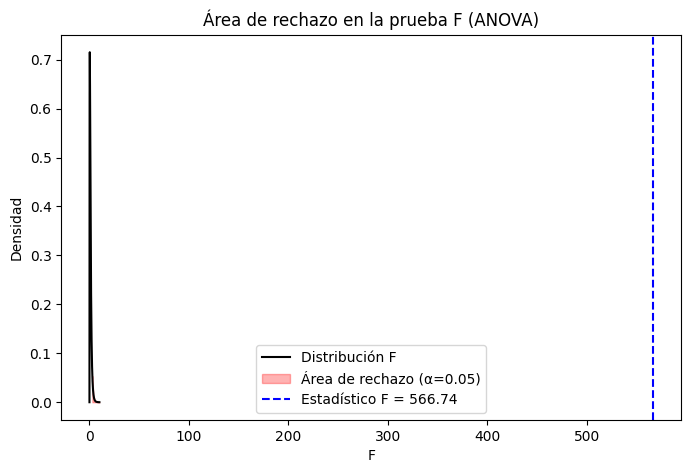


Diferencias significativas detectadas → Aplicando prueba de Tukey...

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper   reject
---------------------------------------------------------------
Condición 1 Condición 2     10.1   0.0   8.2723  11.9277   True
Condición 1 Condición 3     -5.2   0.0  -7.0277  -3.3723   True
Condición 1 Condición 4     20.0   0.0  18.1723  21.8277   True
Condición 2 Condición 3    -15.3   0.0 -17.1277 -13.4723   True
Condición 2 Condición 4      9.9   0.0   8.0723  11.7277   True
Condición 3 Condición 4     25.2   0.0  23.3723  27.0277   True
---------------------------------------------------------------


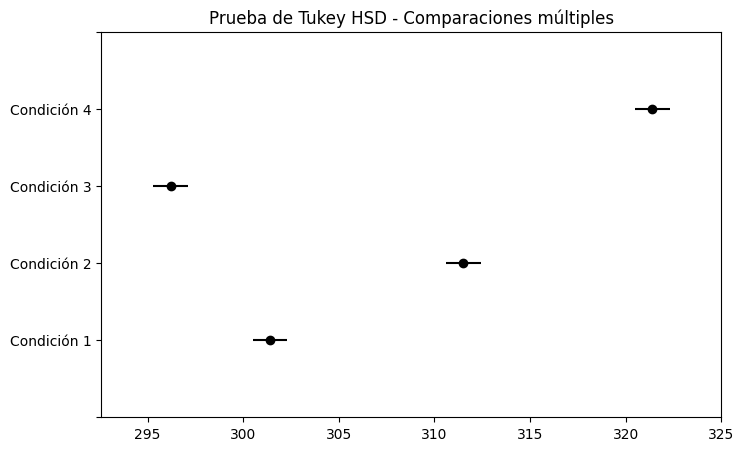

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f

# ==============================
# 1️⃣ Datos del problema
# ==============================
condiciones = {
    'Condición 1': [300, 305, 298, 302, 304, 300, 303, 301, 299, 302],
    'Condición 2': [310, 312, 311, 313, 310, 312, 311, 314, 312, 310],
    'Condición 3': [295, 297, 296, 295, 298, 297, 296, 295, 297, 296],
    'Condición 4': [320, 322, 321, 323, 320, 322, 321, 323, 322, 320],
}

# Supongamos que cada condición fue evaluada por 2 operadores alternando las mediciones
operadores = ['A', 'B'] * 5  # 10 valores por condición → 5 A y 5 B

# Crear el DataFrame
data = []
for i, (cond, valores) in enumerate(condiciones.items()):
    for j, valor in enumerate(valores):
        data.append([cond, operadores[j], valor])

df = pd.DataFrame(data, columns=['Condición', 'Operador', 'Resistencia'])

print("\nDatos del experimento:")
print(df.head())

# ==============================
# 2️⃣ ANOVA de dos vías con interacción
# ==============================
modelo = ols('Resistencia ~ C(Condición) * C(Operador)', data=df).fit()
anova = sm.stats.anova_lm(modelo, typ=2)

print("\n=== Tabla ANOVA (dos vías con interacción) ===")
print(anova)

# ==============================
# 3️⃣ Gráfica del área de rechazo
# ==============================
# Usamos el estadístico F y p-valor del factor Condición
f_stat = anova.loc['C(Condición)', 'F']
p_val = anova.loc['C(Condición)', 'PR(>F)']
df_between = anova.loc['C(Condición)', 'df']
df_within = anova.loc['Residual', 'df']

# Calcular valor crítico F
alpha = 0.05
f_crit = f.ppf(1 - alpha, df_between, df_within)

# Gráfica del área de rechazo
x = np.linspace(0, 10, 500)
y = f.pdf(x, df_between, df_within)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'k', label='Distribución F')
plt.fill_between(x, y, 0, where=(x > f_crit), color='red', alpha=0.3, label='Área de rechazo (α=0.05)')
plt.axvline(f_stat, color='blue', linestyle='--', label=f'Estadístico F = {f_stat:.2f}')
plt.title('Área de rechazo en la prueba F (ANOVA)')
plt.xlabel('F')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# ==============================
# 4️⃣ Prueba de Tukey (si hay diferencia significativa)
# ==============================
if p_val < alpha:
    print("\nDiferencias significativas detectadas → Aplicando prueba de Tukey...\n")
    tukey = pairwise_tukeyhsd(endog=df['Resistencia'],
                              groups=df['Condición'],
                              alpha=0.05)
    print(tukey)
    tukey.plot_simultaneous(figsize=(8, 5))
    plt.title("Prueba de Tukey HSD - Comparaciones múltiples")
    plt.show()
else:
    print("\nNo se detectaron diferencias significativas entre condiciones (p > 0.05)")